In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("dataset/Online Retail.xlsx")

# Display first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Check dataset structure
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# Check cancelled transactions
print("Cancelled transactions:", df["InvoiceNo"].astype(str).str.startswith("C").sum())

# Check missing Customer IDs
print("Missing Customer IDs:", df["CustomerID"].isnull().sum())

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

print("\nCleaned Dataset Shape:", df.shape)
print("Missing Customer IDs after cleaning:", df["CustomerID"].isnull().sum())

Cancelled transactions: 9288
Missing Customer IDs: 135080

Cleaned Dataset Shape: (397884, 8)
Missing Customer IDs after cleaning: 0


In [7]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Set the reference date as one day after the last transaction
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest Transaction Date:", df["InvoiceDate"].max())
print("Reference Date:", reference_date)

Latest Transaction Date: 2011-12-09 12:50:00
Reference Date: 2011-12-10 12:50:00


In [8]:
# Calculate RFM features

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "UnitPrice": "mean"
})

# Rename columns
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency"
}, inplace=True)

# Calculate Monetary value
customer_monetary = (
    df.assign(TotalAmount=df["Quantity"] * df["UnitPrice"])
      .groupby("CustomerID")["TotalAmount"]
      .sum()
)

rfm["Monetary"] = customer_monetary

# Keep only the three required RFM features
rfm = rfm[["Recency", "Frequency", "Monetary"]]

# Display first 5 customers
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [9]:
# Descriptive statistics of RFM features

print("RFM Descriptive Statistics:")
display(rfm.describe())

print("\nAverage Recency:", round(rfm["Recency"].mean(), 2), "days")
print("Average Purchase Frequency:", round(rfm["Frequency"].mean(), 2), "orders")
print("Average Monetary Value:", round(rfm["Monetary"].mean(), 2))

RFM Descriptive Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000



Average Recency: 92.54 days
Average Purchase Frequency: 4.27 orders
Average Monetary Value: 2054.27


In [11]:
from sklearn.preprocessing import StandardScaler

# Select RFM features for clustering
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize the RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert standardized data back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

# Display first 5 standardized records
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.334574,-0.425097,8.358668
12347,-0.905340,0.354417,0.250966
12348,-0.175360,-0.035340,-0.028596
12349,-0.735345,-0.425097,-0.033012
12350,2.174578,-0.425097,-0.191347


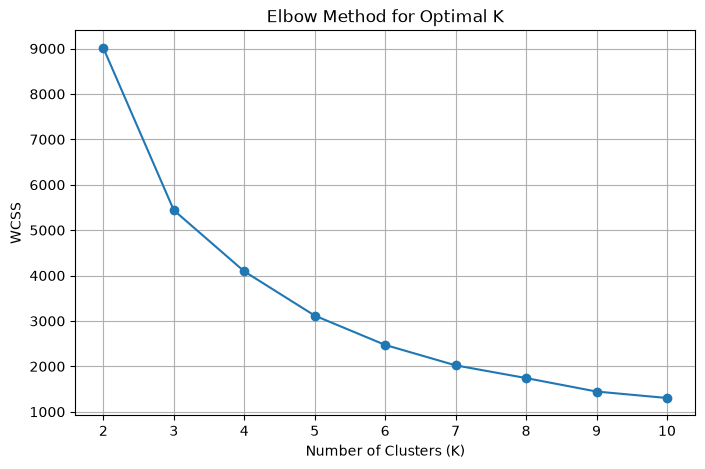

In [12]:
from sklearn.cluster import KMeans

# Calculate WCSS for different numbers of clusters
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [13]:
# Apply K-Means clustering with K = 5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit the model and assign cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display first 10 customers with their cluster
rfm.head(10)

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1
12352,36,8,2506.04,0
12353,204,1,89.00,1
12354,232,1,1079.40,1
12355,214,1,459.40,1


In [14]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

# Count customers in each cluster
cluster_sizes = rfm["Cluster"].value_counts().sort_index()

print("Average RFM Values by Cluster:")
display(cluster_profile)

print("\nNumber of Customers in Each Cluster:")
display(cluster_sizes)

Average RFM Values by Cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,43.95,3.65,1339.07
1,248.56,1.55,478.11
2,15.67,21.29,12831.74
3,6.50,120.50,55312.69
4,7.67,42.83,190863.46



Number of Customers in Each Cluster:


Cluster
0    3049
1    1062
2     213
3       8
4       6
Name: count, dtype: int64

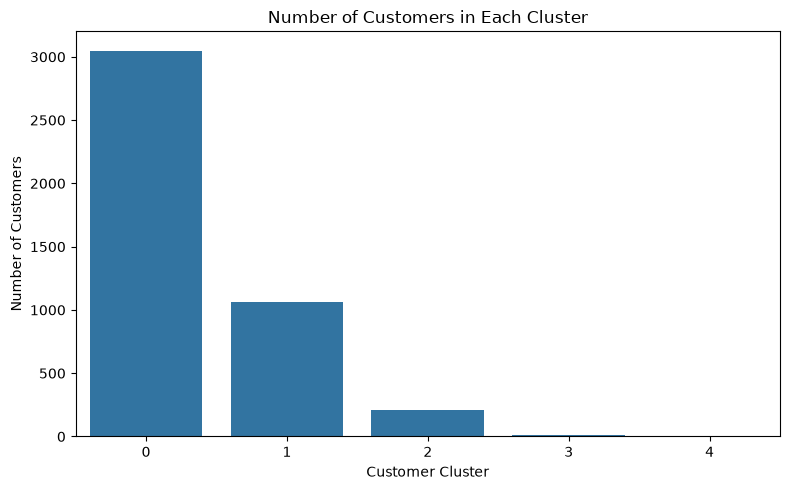

In [15]:
# Number of customers in each cluster

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_sizes.index,
    y=cluster_sizes.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

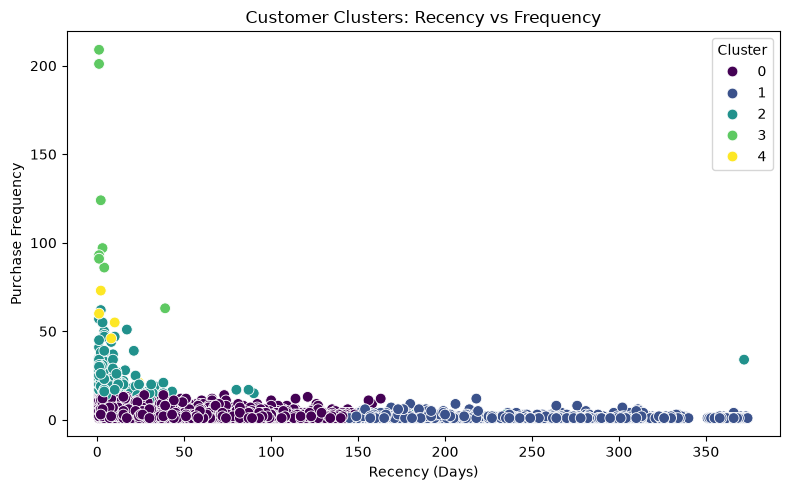

In [16]:
# Scatter Plot: Recency vs Frequency

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Clusters: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

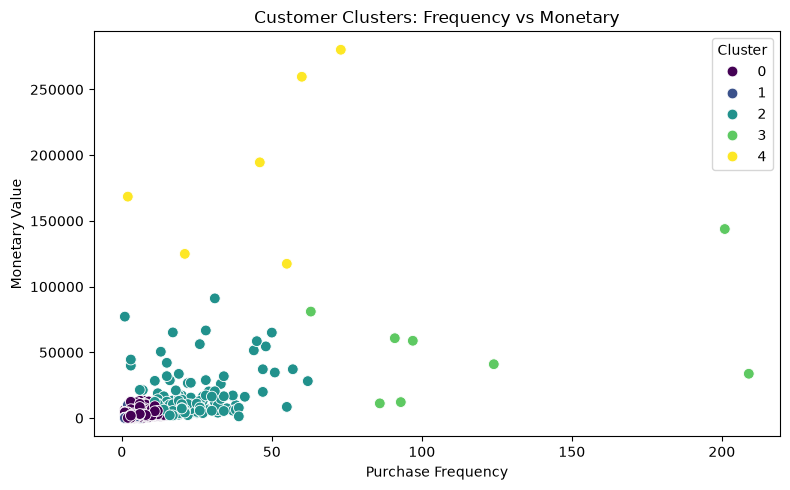

In [17]:
# Scatter Plot: Frequency vs Monetary

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

## Cluster Insights and Marketing Recommendations

Based on RFM analysis and K-Means clustering, customers were divided into five segments.

### Cluster 0 – Regular / Low-Value Customers
- Customers: 3,049
- Average Recency: 43.95 days
- Average Frequency: 3.65 orders
- Average Monetary Value: 1,339.07
- These customers purchase relatively regularly but have moderate spending.
- **Marketing Action:** Use personalized product recommendations, loyalty points, and cross-selling offers to increase their purchase frequency and spending.

### Cluster 1 – Inactive / At-Risk Customers
- Customers: 1,062
- Average Recency: 248.56 days
- Average Frequency: 1.55 orders
- Average Monetary Value: 478.11
- These customers have not purchased recently and show low purchase frequency and spending.
- **Marketing Action:** Run re-engagement campaigns, limited-time discounts, reminder emails, and special offers to encourage repeat purchases.

### Cluster 2 – Loyal High-Value Customers
- Customers: 213
- Average Recency: 15.67 days
- Average Frequency: 21.29 orders
- Average Monetary Value: 12,831.74
- These customers purchase frequently, purchased recently, and generate high revenue.
- **Marketing Action:** Reward them with loyalty benefits, early access to new products, personalized offers, and premium customer service.

### Cluster 3 – Very High-Value / VIP Customers
- Customers: 8
- Average Recency: 6.50 days
- Average Frequency: 120.50 orders
- Average Monetary Value: 55,312.69
- This is a very small but highly active and valuable customer segment.
- **Marketing Action:** Provide VIP membership, exclusive products, priority support, and personalized relationship management.

### Cluster 4 – Exceptional High-Spending Customers
- Customers: 6
- Average Recency: 7.67 days
- Average Frequency: 42.83 orders
- Average Monetary Value: 190,863.46
- This segment contains very few customers but has exceptionally high monetary value.
- **Marketing Action:** Focus on customer retention, premium services, personalized communication, and dedicated account management.

### Overall Insights

- Cluster 0 represents the largest customer segment.
- Cluster 1 requires re-engagement because of its high recency and low purchase activity.
- Clusters 2, 3, and 4 are highly valuable segments and should receive stronger retention efforts.
- Clusters 3 and 4 are very small segments but have exceptionally high spending and purchase frequency.
- RFM-based segmentation can help the business create targeted marketing strategies instead of treating all customers equally.

## Conclusion

Customer Segmentation Analysis was performed using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering.

The Elbow Method was used to determine the optimal number of clusters, and five customer segments were identified. The clusters revealed clear differences in customer recency, purchase frequency, and monetary contribution.

The analysis identified regular customers, inactive or at-risk customers, loyal high-value customers, and small but exceptionally valuable VIP segments. These insights can help businesses develop targeted marketing strategies, improve customer retention, and focus resources on high-value customer groups.

Overall, RFM-based K-Means clustering provides an effective data-driven approach for understanding customer behavior and supporting personalized marketing decisions.